In [14]:
import random

In [15]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [16]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [17]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.886008,-0.341415,1.547627,0.242152,-0.254743,0
1,-3.225113,-1.623627,-0.585797,-0.454121,-0.583341,1
2,-3.248303,-0.784419,1.244612,0.181364,-1.582272,1
3,-3.638458,-0.964503,-0.730303,-0.895219,-0.662244,1
4,-0.863099,-1.566530,1.583621,1.468869,-1.291361,0


In [18]:

# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)
     

# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [19]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [20]:
df1 = combined_sampling(df,0.5,0.5)

C:\Users\jaidh\AppData\Local\Temp\ipykernel_26484\1781568095.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [21]:
df2 = combined_sampling(df,0.5,0.5)

C:\Users\jaidh\AppData\Local\Temp\ipykernel_26484\1781568095.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [22]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\jaidh\AppData\Local\Temp\ipykernel_26484\1781568095.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [23]:

print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col1', 'target'], dtype='object')
Index(['col4', 'col1', 'target'], dtype='object')
Index(['col3', 'col5', 'target'], dtype='object')


In [24]:
df3

,col3,col5,target
46,2.682155,-1.910411,0
11,4.106461,3.738554,1
63,1.248605,-0.875660,0
38,-0.480579,0.075070,0
48,1.013456,-0.382862,0
63,1.248605,-0.875660,0
91,1.799260,-0.291625,1
95,0.866899,-1.115103,0
78,0.666058,-1.232531,0
40,0.825116,-1.600996,1


In [25]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()
     
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])
     

DecisionTreeClassifier()

[Text(0.5, 0.9444444444444444, 'x[1] <= -1.414\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.3333333333333333, 0.8333333333333334, 'x[1] <= -2.122\ngini = 0.42\nsamples = 30\nvalue = [9, 21]'),
 Text(0.41666666666666663, 0.8888888888888888, 'True  '),
 Text(0.2, 0.7222222222222222, 'x[1] <= -2.402\ngini = 0.498\nsamples = 15\nvalue = [8, 7]'),
 Text(0.13333333333333333, 0.6111111111111112, 'x[1] <= -3.261\ngini = 0.463\nsamples = 11\nvalue = [4, 7]'),
 Text(0.06666666666666667, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2, 0.5, 'x[0] <= 0.871\ngini = 0.346\nsamples = 9\nvalue = [2, 7]'),
 Text(0.13333333333333333, 0.3888888888888889, 'x[1] <= -2.824\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.06666666666666667, 0.2777777777777778, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.2, 0.2777777777777778, 'x[0] <= -0.934\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.13333333333333333, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1

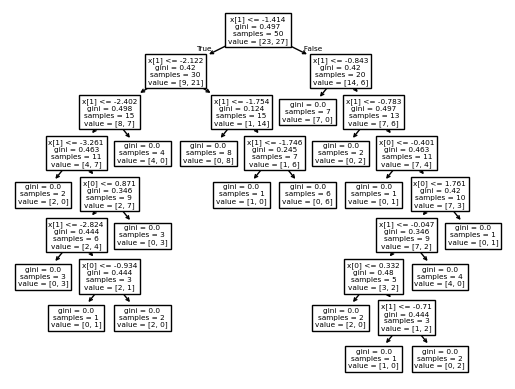

In [26]:
from sklearn.tree import plot_tree
plot_tree(clf1)

[Text(0.375, 0.9444444444444444, 'x[1] <= 0.058\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.3194444444444444, 0.8333333333333334, 'x[0] <= -0.724\ngini = 0.494\nsamples = 45\nvalue = [20, 25]'),
 Text(0.3472222222222222, 0.8888888888888888, 'True  '),
 Text(0.2638888888888889, 0.7222222222222222, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.375, 0.7222222222222222, 'x[0] <= 0.123\ngini = 0.499\nsamples = 42\nvalue = [20, 22]'),
 Text(0.16666666666666666, 0.6111111111111112, 'x[1] <= -1.765\ngini = 0.375\nsamples = 12\nvalue = [9, 3]'),
 Text(0.1111111111111111, 0.5, 'x[0] <= -0.278\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.05555555555555555, 0.3888888888888889, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.16666666666666666, 0.3888888888888889, 'x[0] <= -0.078\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.1111111111111111, 0.2777777777777778, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2222222222222222, 0.2777777777777778, 'gini = 0.0

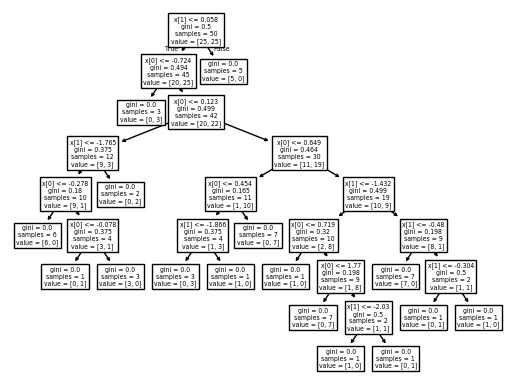

In [27]:
plot_tree(clf2)

[Text(0.4583333333333333, 0.875, 'x[1] <= -0.769\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.25, 0.625, 'x[0] <= 0.842\ngini = 0.105\nsamples = 18\nvalue = [17, 1]'),
 Text(0.35416666666666663, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'x[1] <= -1.555\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.08333333333333333, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.6666666666666666, 0.625, 'x[0] <= -0.208\ngini = 0.375\nsamples = 32\nvalue = [8, 24]'),
 Text(0.5625, 0.75, '  False'),
 Text(0.5, 0.375, 'x[1] <= -0.197\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.4166666666666667, 0.125, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.5833333333333334, 0.125, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.8333333333333334, 0.375, 'x[1] <= -0.357\ngini = 0.165\nsamples = 22\nvalue = [2, 20]'),
 T

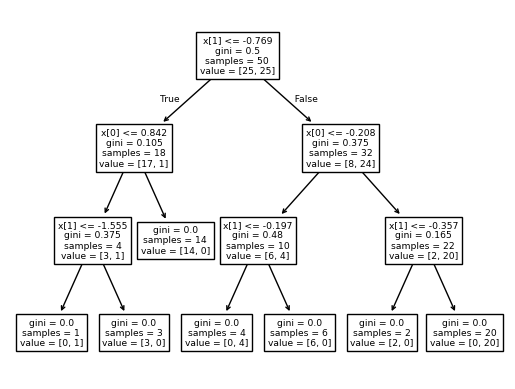

In [28]:
plot_tree(clf3)

In [29]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\jaidh\build\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])